In [76]:
# Instalación de dependencias (ejecutar una vez por entorno)
import sys
import subprocess
import importlib

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
}

missing = [pkg_name for module_name, pkg_name in required_packages.items() if importlib.util.find_spec(module_name) is None]

if missing:
    print(f"Instalando paquetes faltantes: {', '.join(missing)}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing])
else:
    print("Todas las dependencias ya están instaladas.")

Todas las dependencias ya están instaladas.


# EDA Orientado al Modelado — Morosidad Arancelaria UNSTA

Este notebook parte del dataset ya limpio y procesado (`dataset_morosidad_limpio.csv`) generado en `eda_morosidad.ipynb`.  
El objetivo no es volver a limpiar datos sino **entender los patrones que guiarán las decisiones del modelo**:

1. Balance de clases y estrategia ante el imbalance
2. Distribución de features vs `target_mora_genuina`
3. Patrones estacionales (cuota, mes, semestre)
4. Correlaciones y multicolinealidad
5. Integración con datos reales 2025/2026 (deudores actuales)
6. Conclusiones → features a usar, descartar, estrategia de modelado

---
## Glosario de variables y targets

Esta seccion explica las variables clave del dataset y como se construyo el target principal antes de comenzar el analisis.

---

### 1. Como se clasifica cada cuota (variable interna `tipo_mora`)

Cada cuota del dataset se clasifica segun cuando pago el alumno respecto a los vencimientos reales:

| Categoria | Condicion | Interpretacion |
|---|---|---|
| `en_termino` | Pago antes del 1er vencimiento | Pago a tiempo |
| `mora_leve` | Pago entre el 1er y 2do vencimiento | Pago con leve retraso (dias habiles) |
| `mora_media` | Pago entre el 2do y 3er vencimiento | Pago con retraso medio |
| `mora_grave` | Pago despues del 3er vencimiento | Pago muy tarde |
| `sin_pago` | Sin fecha de pago registrada | No pago (puede ser mora real o abandono) |

Los vencimientos reales se calculan a partir del 1ro del mes usando dias habiles (con feriados argentinos): 1ro = 5 dias habiles, 2do = 15 dias habiles, 3ro = fin de mes.

---

### 2. Descomposicion del `sin_pago` (variable interna `subtipo_sin_pago`)

El `sin_pago` crudo incluye situaciones muy distintas. Se descompone en subcategorias para separar mora genuina de abandono:

| Subcategoria | Condicion | Mora genuina? |
|---|---|---|
| `sin_pago_real` | No pago y no encaja en ningun patron de abandono | **Si** |
| `mora_leve` | (viene de tipo_mora, no es sin_pago) | **Si** |
| `mora_media` | (viene de tipo_mora, no es sin_pago) | **Si** |
| `mora_grave` | (viene de tipo_mora, no es sin_pago) | **Si** |
| `abandono_temporal` | La cuota pertenece a un periodo justo antes de una brecha (el alumno se fue y volvio al año siguiente) | No |
| `abandono_definitivo` | El ultimo periodo del alumno es anterior al periodo actual y no hubo retorno | No |
| `excedio_duracion` | El alumno lleva mas años que la duracion teorica de la carrera (posible egresado sin baja o rezago extremo) | No |

Esta descomposicion es clave: sin ella, alumnos que simplemente dejaron la carrera (abandono) inflan artificialmente la tasa de mora.

---

### 3. Targets del modelo

| Target | Definicion | Cuando vale 1 |
|---|---|---|
| `target_mora_genuina` | **Target principal.** Mora real excluyendo abandonos. | `mora_leve` + `mora_media` + `mora_grave` + `sin_pago_real` |
| `target_impago` | Solo el impago mas estricto (cuotas que nunca se pagaron y son mora real). | Solo `sin_pago_real` |
| `target_pago_mes` | El alumno no pago dentro del mes de vencimiento. | `mora_media` + `mora_grave` + `sin_pago_real` |
| `target_no_pago` | Target original del sistema (sin depurar). | Cualquier `sin_pago`, incluyendo abandonos (menos preciso) |

> **Por que usar `target_mora_genuina` y no `target_no_pago`?**  
> El `target_no_pago` original incluye alumnos que abandonaron la carrera. Un modelo entrenado con ese target aprenderia a predecir abandono + mora juntos, lo que distorsiona las predicciones para alumnos activos. El `target_mora_genuina` solo marca cuotas donde el alumno **estaba activo y no pago**.

---

### 4. Variables del dataset

#### Variables conductuales (comportamiento de pago - las mas predictivas)

| Variable | Descripcion | Valores |
|---|---|---|
| `pago_cuota_anterior` | Si el alumno pago la cuota inmediatamente anterior en termino | `1` = pago, `0` = no pago, `-1` = sin historial (primera cuota) |
| `mora_genuina_cuota_anterior` | Si la cuota anterior fue mora genuina | `1` = si, `0` = no, `-1` = sin historial |
| `racha_mora_consecutiva` | Cuantas cuotas seguidas lleva el alumno en mora genuina | Entero >= 0 |
| `hist_ratio_pago` | Proporcion historica de cuotas que el alumno pago (acumulado de periodos anteriores) | 0.0 a 1.0 (0 = nunca pago, 1 = siempre pago) |
| `hist_ratio_en_termino` | Proporcion historica de cuotas pagadas en termino | 0.0 a 1.0 |
| `hist_ratio_mora_genuina` | Proporcion historica de cuotas con mora genuina | 0.0 a 1.0 |
| `hist_dias_atraso_prom` | Promedio historico de dias habiles de atraso al pagar | Dias habiles >= 0 |
| `tendencia_pago` | Diferencia entre el ratio de pago del periodo anterior y el promedio historico. Positivo = mejoro; negativo = empeoro | Decimal |
| `mejoro_vs_periodo_anterior` | Si el ratio de pago del ultimo periodo fue mejor que el periodo previo | `1` = mejoro, `0` = igual o empeoro |

#### Variables de contexto de carrera

| Variable | Descripcion | Valores |
|---|---|---|
| `mora_promedio_carrera` | Tasa de mora historica promedio de la carrera del alumno (calculada con periodos anteriores para evitar data leakage) | 0.0 a 1.0 |
| `mora_promedio_cohorte` | Tasa de mora promedio del cohorte del alumno (mismo año de ingreso y carrera) | 0.0 a 1.0 |
| `mora_vs_cohorte` | Diferencia entre la mora del alumno y la mora promedio de su cohorte. Negativo = mejor que su cohorte | Decimal |

#### Variables de trayectoria academica

| Variable | Descripcion | Valores |
|---|---|---|
| `pct_avance_carrera` | Porcentaje de la carrera completado al momento de la cuota (anios_en_carrera / duracion_teorica). >1.0 = rezago | 0.0 a 2.0 (clippeado) |
| `anios_en_carrera` | Cuántos años lleva inscripto el alumno desde su ingreso | Entero >= 0 |
| `tiene_brecha` | El alumno interrumpio la carrera al menos un año completo y luego retorno | `1` = tuvo brecha, `0` = sin interrupciones |
| `periodos_previos` | Cuantos periodos academicos tuvo el alumno antes del periodo actual | Entero >= 0 |
| `es_ultimo_anio_esperado` | El alumno esta en el tramo final de su carrera (pct_avance >= 85%) | `1` = si, `0` = no, `-1` = sin dato |
| `excedio_duracion` | El alumno supero la duracion teorica de su carrera | `1` = si, `0` = no |

#### Variables dentro del periodo actual

| Variable | Descripcion | Valores |
|---|---|---|
| `cuotas_pagadas_periodo_actual` | Cuantas cuotas ya pago el alumno en el periodo actual, antes de la cuota analizada (anti-leakage: shift(1)) | Entero >= 0 |
| `ratio_pago_periodo_actual` | Proporcion de cuotas pagadas en lo que va del periodo actual (antes de la cuota analizada) | 0.0 a 1.0 |

#### Variables arancelarias y temporales

| Variable | Descripcion | Valores |
|---|---|---|
| `pct_descuento` | Porcentaje de descuento sobre el arancel (categoria arancelaria: beca, convenio, etc.) | 0 a 100 |
| `nro_cuota` | Numero de cuota dentro del año (1 = marzo, 12 = febrero) | 1 a 12 |
| `semestre` | Semestre al que pertenece la cuota | `1` = cuotas 1-6, `2` = cuotas 7-12 |
| `mes_vencimiento` | Mes calendario de vencimiento de la cuota | 1 a 12 |
| `es_pandemia` | Si la cuota corresponde a un periodo de pandemia (2020-2021) | `1` = si, `0` = no |
| `edad_al_vencer` | Edad del alumno al momento del vencimiento de la cuota | Anios (aprox. 18 a 60+) |

---


## 1. Setup e imports

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 5)

DATA_DIR = Path('../training/data')

print('Setup OK')

Setup OK


## 2. Carga del dataset limpio

In [78]:
df = pd.read_csv(
    DATA_DIR / 'dataset_morosidad_limpio.csv',
    parse_dates=['fecha_vencimiento', 'fecha_pago', 'venc_1_real', 'venc_2_real', 'venc_3_real'],
    low_memory=False
)

print(f'Filas:    {len(df):,}')
print(f'Columnas: {df.shape[1]}')
print(f'Períodos: {sorted(df["periodo"].unique())}')
print(f'Alumnos únicos: {df["id_alumno"].nunique():,}')
print()
print('=== Columnas disponibles ===')
for col in df.columns:
    print(f'  {col}: {df[col].dtype}  | nulos: {df[col].isna().sum()}')

Filas:    461,984
Columnas: 65
Períodos: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Alumnos únicos: 24,127

=== Columnas disponibles ===
  id_alumno: int64  | nulos: 0
  id_persona: int64  | nulos: 0
  periodo: int64  | nulos: 0
  nro_cuota: int64  | nulos: 0
  fecha_vencimiento: datetime64[us]  | nulos: 0
  id_carrera: str  | nulos: 0
  id_sede_academica: int64  | nulos: 0
  id_unidad_academica: int64  | nulos: 0
  id_facultad: str  | nulos: 0
  id_categoria_arancelaria: int64  | nulos: 0
  pct_descuento: float64  | nulos: 0
  cod_categoria: str  | nulos: 0
  sexo: str  | nulos: 422
  edad_al_vencer: float64  | nulos: 7770
  discapacidad: int64  | nulos: 0
  id_localidad: float64  | nulos: 408977
  id_provincia: float64  | nulos: 408577
  contexto_temporal: str  | nulos: 0
  fecha_pago: datetime64[us]  | nulos: 142582
  nro_venc_usado: float64  | nulos: 142582
  dias_atraso: float64  | nulos: 142582
  target_no_pago: int64  | nulos

In [79]:
# Targets disponibles
TARGET_COLS = ['target_mora_genuina', 'target_pago_mes', 'target_impago', 'target_no_pago']
print('=== Distribución de targets ===')
for t in TARGET_COLS:
    if t in df.columns:
        vc = df[t].value_counts(dropna=False)
        pct = df[t].value_counts(normalize=True, dropna=False) * 100
        print(f'\n{t}:')
        for v in vc.index:
            print(f'  {v}: {vc[v]:>8,}  ({pct[v]:.1f}%)')

=== Distribución de targets ===

target_mora_genuina:
  1:  258,195  (55.9%)
  0:  203,789  (44.1%)

target_pago_mes:
  0:  363,807  (78.7%)
  1:   98,177  (21.3%)

target_impago:
  0:  426,946  (92.4%)
  1:   35,038  (7.6%)

target_no_pago:
  1:  332,187  (71.9%)
  0:  129,797  (28.1%)


## 3. Balance de clases y estrategia de imbalance

Antes de analizar features, entendemos el desbalance del target principal `target_mora_genuina`.

In [80]:
TARGET = 'target_mora_genuina'
df_modelo = df[df[TARGET].notna()].copy()

n_total = len(df_modelo)
n_mora  = df_modelo[TARGET].sum()
n_ok    = n_total - n_mora
ratio   = n_ok / n_mora

print(f'Dataset para modelado: {n_total:,} filas')
print(f'  Sin mora  (0): {n_ok:>8,}  ({n_ok/n_total*100:.1f}%)')
print(f'  Con mora  (1): {n_mora:>8,}  ({n_mora/n_total*100:.1f}%)')
print(f'  Ratio positivo/negativo: 1 : {ratio:.2f}')
print()

# Distribucion por año
print('=== Tasa de mora genuina por período ===')
by_periodo = df_modelo.groupby('periodo')[TARGET].agg(['mean','sum','count'])
by_periodo.columns = ['tasa_mora', 'n_mora', 'n_total']
by_periodo['tasa_mora_pct'] = (by_periodo['tasa_mora'] * 100).round(1)
print(by_periodo[['n_total','n_mora','tasa_mora_pct']].to_string())

Dataset para modelado: 461,984 filas
  Sin mora  (0):  203,789  (44.1%)
  Con mora  (1):  258,195  (55.9%)
  Ratio positivo/negativo: 1 : 0.79

=== Tasa de mora genuina por período ===
         n_total  n_mora  tasa_mora_pct
periodo                                
2020       63215   42477           67.2
2021       69860   41867           59.9
2022       78116   45296           58.0
2023       87627   47237           53.9
2024       85039   44106           51.9
2025       78127   37212           47.6


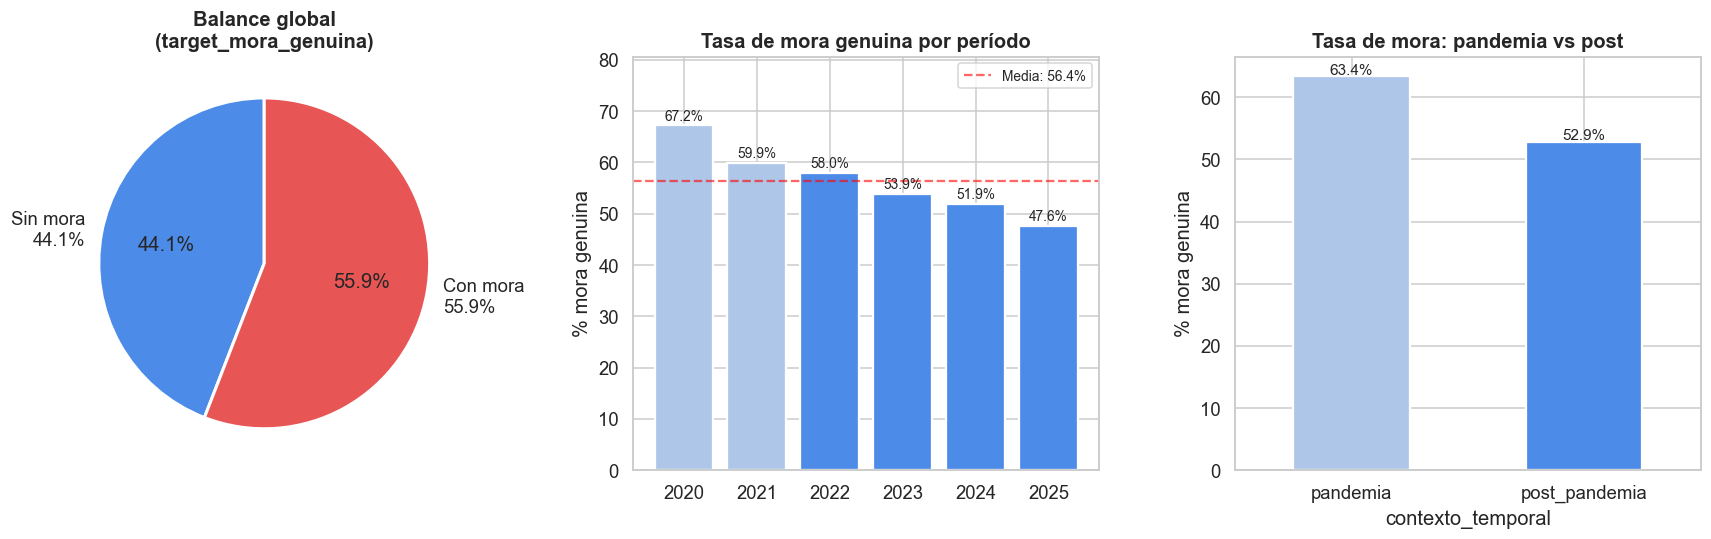

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Gráfico 1: Pie balance global ---
axes[0].pie(
    [n_ok, n_mora],
    labels=[f'Sin mora\n{n_ok/n_total*100:.1f}%', f'Con mora\n{n_mora/n_total*100:.1f}%'],
    colors=['#4c8be8', '#e85555'],
    startangle=90, autopct='%1.1f%%',
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Balance global\n(target_mora_genuina)', fontweight='bold')

# --- Gráfico 2: Tasa de mora por período ---
periodos = by_periodo.index.tolist()
tasas    = by_periodo['tasa_mora_pct'].tolist()
colors   = ['#aec6e8' if p <= 2021 else '#4c8be8' for p in periodos]
bars = axes[1].bar(periodos, tasas, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Tasa de mora genuina por período', fontweight='bold')
axes[1].set_ylabel('% mora genuina')
axes[1].set_ylim(0, max(tasas) * 1.2)
for bar, t in zip(bars, tasas):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{t:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].axhline(np.mean(tasas), color='red', linestyle='--', alpha=0.6, label=f'Media: {np.mean(tasas):.1f}%')
axes[1].legend(fontsize=9)

# --- Gráfico 3: Mora pandemia vs post ---
ctx_mora = df_modelo.groupby('contexto_temporal')[TARGET].mean() * 100
ctx_mora.plot(kind='bar', ax=axes[2], color=['#aec6e8', '#4c8be8'], edgecolor='white', linewidth=1.5)
axes[2].set_title('Tasa de mora: pandemia vs post', fontweight='bold')
axes[2].set_ylabel('% mora genuina')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
for i, v in enumerate(ctx_mora):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
DOCS_DIR = Path('../docs')
DOCS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(DOCS_DIR / 'eda_balance_clases.png', bbox_inches='tight')
plt.show()

### Como leer este grafico - Balance de clases y contexto historico

- **Izquierda - Torta de balance global:** proporcion de cuotas con mora genuina vs. sin mora. Un desbalance severo (ej. 85%/15%) indica que el modelo necesita tecnicas de balanceo (SMOTE, class_weight, undersampling) para no ignorar la clase minoritaria.
- **Centro - Tasa de mora por periodo:** evolucion año a año. Barras azul claro = años pre-2022; azul oscuro = mas recientes. Linea roja punteada = media historica. Picos hacia arriba = años con mayor estres de pago (ej. pandemia 2020-2021).
- **Derecha - Pandemia vs. post pandemia:** comparacion directa de mora en contexto pandemico (2020-2021) versus el resto. Ayuda a decidir si `es_pandemia` aporta como feature o si ya queda absorbida por otras variables.

In [82]:
# Recomendación automática de estrategia
print('=== Recomendación de estrategia ante imbalance ===')
print(f'Ratio: 1:{ratio:.1f}  →  ', end='')
if ratio < 3:
    print('Desbalance leve. class_weight="balanced" es suficiente.')
elif ratio < 10:
    print('Desbalance moderado. Opciones: class_weight + ajuste de umbral de decisión.')
else:
    print('Desbalance severo. Considerar SMOTE o undersampling + class_weight.')
print()
print('Estrategias a comparar en el entrenamiento:')
print('  1. class_weight="balanced" (más simple, recomendado para arrancar)')
print('  2. Ajuste de umbral de clasificación (optimizar F1 o Recall según negocio)')
print('  3. SMOTE sobre conjunto de entrenamiento (solo si ratio > 5:1)')

=== Recomendación de estrategia ante imbalance ===
Ratio: 1:0.8  →  Desbalance leve. class_weight="balanced" es suficiente.

Estrategias a comparar en el entrenamiento:
  1. class_weight="balanced" (más simple, recomendado para arrancar)
  2. Ajuste de umbral de clasificación (optimizar F1 o Recall según negocio)
  3. SMOTE sobre conjunto de entrenamiento (solo si ratio > 5:1)


## 4. Distribución de features vs target

Para cada feature relevante: ¿discrimina entre mora y no mora?

### 4.1 Features conductuales (las más importantes)

Estas son las features con mayor potencial predictivo porque capturan el comportamiento histórico del alumno.

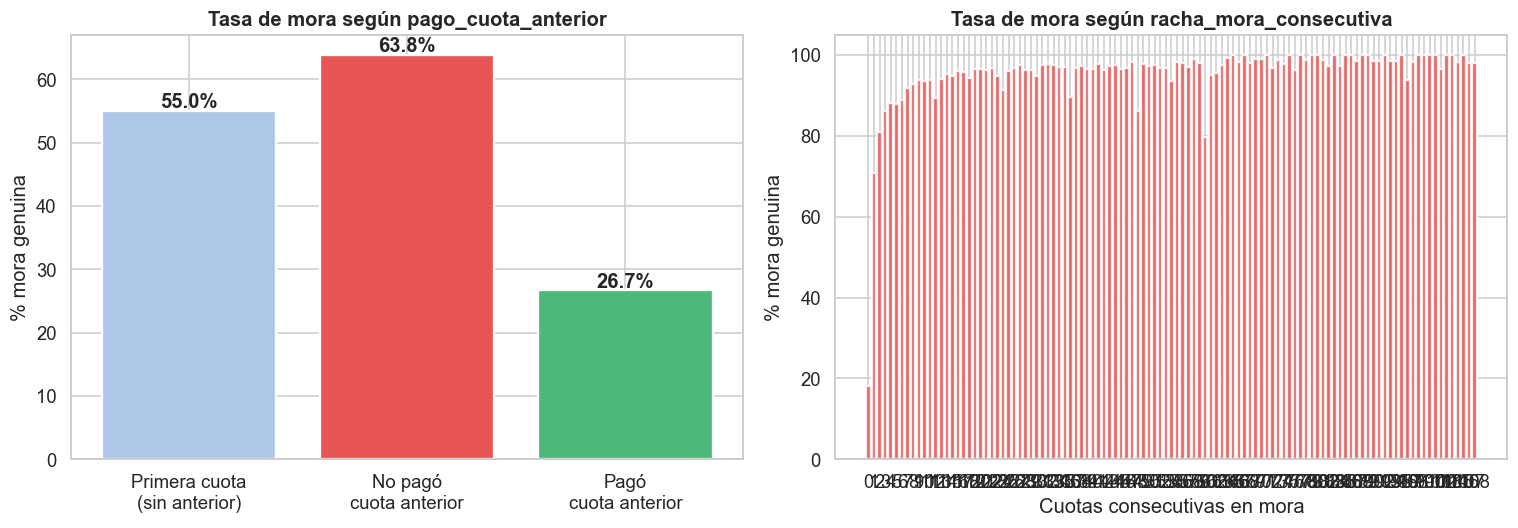


=== Poder predictivo pago_cuota_anterior ===
  Primera cuota
(sin anterior): 55.0% de mora
  No pagó
cuota anterior: 63.8% de mora
  Pagó
cuota anterior: 26.7% de mora


In [83]:
# --- pago_cuota_anterior: ¿pagó la cuota inmediatamente anterior? ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de mora según si pagó o no la cuota anterior
pca_mora = df_modelo.groupby('pago_cuota_anterior')[TARGET].mean() * 100
labels = {-1: 'Primera cuota\n(sin anterior)', 0: 'No pagó\ncuota anterior', 1: 'Pagó\ncuota anterior'}
pca_mora.index = [labels.get(i, str(i)) for i in pca_mora.index]
colors = ['#aec6e8', '#e85555', '#4cb87a']
bars = axes[0].bar(pca_mora.index, pca_mora.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Tasa de mora según pago_cuota_anterior', fontweight='bold')
axes[0].set_ylabel('% mora genuina')
for bar, v in zip(bars, pca_mora.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold')

# racha_mora_consecutiva vs tasa de mora
racha_mora = df_modelo.groupby('racha_mora_consecutiva')[TARGET].agg(['mean','count'])
racha_mora = racha_mora[racha_mora['count'] > 50]  # solo grupos con suficientes muestras
racha_mora['mean_pct'] = racha_mora['mean'] * 100
axes[1].bar(racha_mora.index.astype(str), racha_mora['mean_pct'],
            color='#e85555', alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].set_title('Tasa de mora según racha_mora_consecutiva', fontweight='bold')
axes[1].set_ylabel('% mora genuina')
axes[1].set_xlabel('Cuotas consecutivas en mora')

plt.tight_layout()
plt.show()

print('\n=== Poder predictivo pago_cuota_anterior ===')
for k, v in zip(pca_mora.index, pca_mora.values):
    print(f'  {k}: {v:.1f}% de mora')

### Como leer este grafico - Comportamiento reciente de pago

- **Izquierda - pago_cuota_anterior:** tres barras que muestran la tasa de mora segun si el alumno pago la cuota inmediatamente anterior. 'Primera cuota' = sin cuota previa. 'No pago' = cuota anterior impaga. 'Pago' = cuota anterior al dia. La brecha entre 'Pago' y 'No pago' es el poder predictivo de esta variable: cuanto mayor, mas señal aporta al modelo.
- **Derecha - racha_mora_consecutiva:** cuantas cuotas seguidas lleva el alumno en mora. A mayor racha, mayor tasa de mora actual, validando la inercia del comportamiento de pago.

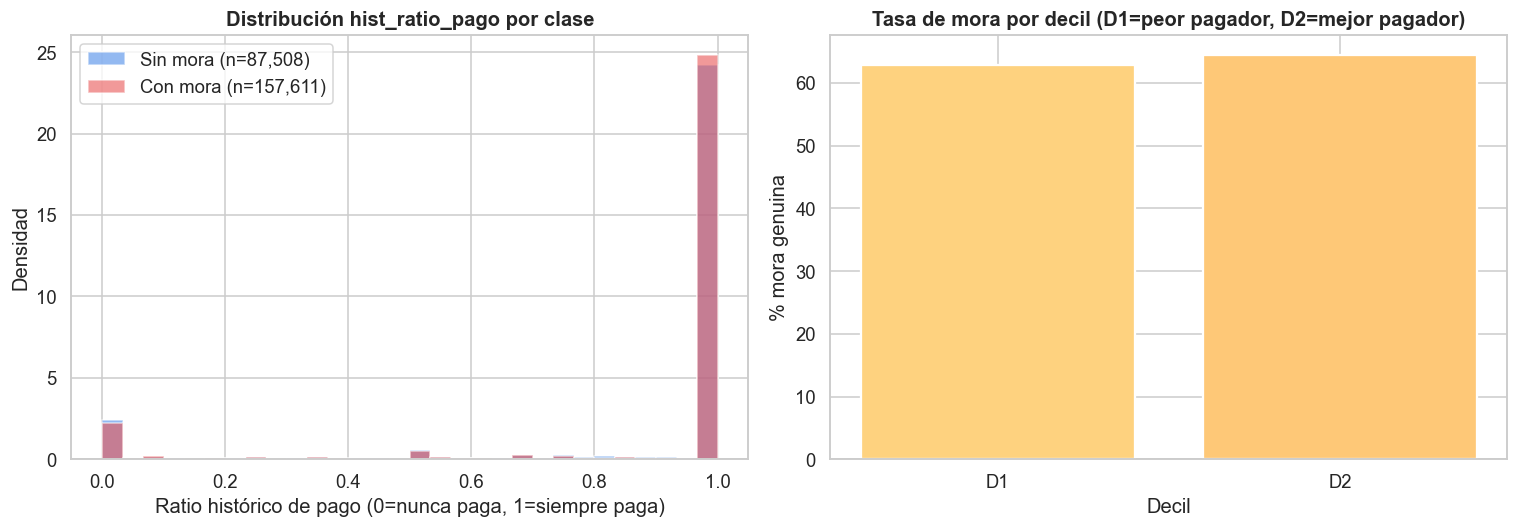

In [84]:
# --- hist_ratio_pago: tasa histórica de pago del alumno ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de hist_ratio_pago por clase
df_con_hist = df_modelo[df_modelo['hist_ratio_pago'].notna()]
nombres = {0: 'Sin mora', 1: 'Con mora'}
for label, color in [(0, '#4c8be8'), (1, '#e85555')]:
    subset = df_con_hist[df_con_hist[TARGET] == label]['hist_ratio_pago']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f'{nombres[label]} (n={len(subset):,})',
                 density=True)
axes[0].set_title('Distribución hist_ratio_pago por clase', fontweight='bold')
axes[0].set_xlabel('Ratio histórico de pago (0=nunca paga, 1=siempre paga)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Tasa de mora por deciles — labels=False evita error cuando duplicates='drop' reduce bins
df_con_hist = df_con_hist.copy()
df_con_hist['decil_num'], bin_edges = pd.qcut(
    df_con_hist['hist_ratio_pago'], q=10,
    labels=False, duplicates='drop', retbins=True
)
n_bins = len(bin_edges) - 1
df_con_hist['decil_hist_pago'] = df_con_hist['decil_num'].apply(
    lambda x: f'D{int(x)+1}' if pd.notna(x) else np.nan
)
mora_decil = df_con_hist.groupby('decil_hist_pago', observed=True)[TARGET].mean() * 100
mora_decil = mora_decil.reindex(sorted(mora_decil.index, key=lambda x: int(x[1:])))

titulo = 'Tasa de mora por decil (D1=peor pagador, D' + str(n_bins) + '=mejor pagador)'
bars = axes[1].bar(mora_decil.index.astype(str), mora_decil.values,
                   color=plt.cm.RdYlGn_r(mora_decil.values / 100),
                   edgecolor='white', linewidth=1.5)
axes[1].set_title(titulo, fontweight='bold')
axes[1].set_ylabel('% mora genuina')
axes[1].set_xlabel('Decil')

plt.tight_layout()
plt.show()


### Como leer este grafico - Historial de ratio de pago

- **Izquierda - Distribucion hist_ratio_pago:** histograma de densidad superpuesto para alumnos con mora (rojo) y sin mora (azul). Eje X: ratio historico de pago (0 = nunca pago en termino, 1 = siempre pago en termino). Cuanto mas separadas esten las curvas, mas discrimina la variable.
- **Derecha - Tasa de mora por decil:** el historial se divide en 10 grupos (D1 = peores pagadores, D10 = mejores). Colores de rojo a verde. Una barra D1 muy alta confirma que el historial predice bien la mora actual.

/var/folders/b4/d1fzz9h972v_gy_9myprsdj40000gn/T/ipykernel_48323/1543701810.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')


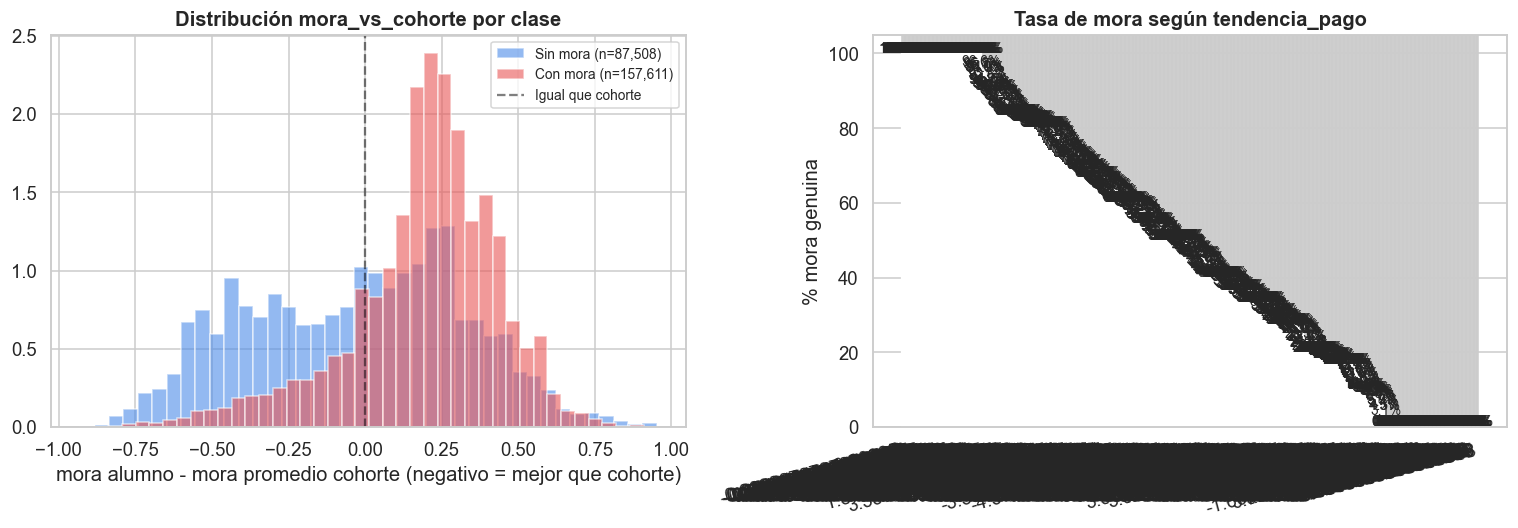

In [85]:
# --- mora_vs_cohorte: ¿el alumno es peor o mejor que su cohorte? ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_mvc = df_modelo[df_modelo['mora_vs_cohorte'].notna()]

for label, color in [(0, '#4c8be8'), (1, '#e85555')]:
    subset = df_mvc[df_mvc[TARGET] == label]['mora_vs_cohorte']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color,
                 label=f'{"Con mora" if label else "Sin mora"} (n={len(subset):,})',
                 density=True)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5, label='Igual que cohorte')
axes[0].set_title('Distribución mora_vs_cohorte por clase', fontweight='bold')
axes[0].set_xlabel('mora alumno - mora promedio cohorte (negativo = mejor que cohorte)')
axes[0].legend(fontsize=9)

# Tendencia de pago
if 'tendencia_pago' in df_modelo.columns:
    tend_mora = df_modelo.groupby('tendencia_pago')[TARGET].mean() * 100
    tend_mora = tend_mora.sort_values(ascending=False)
    colors_t = ['#e85555' if v > 40 else '#f5a623' if v > 20 else '#4cb87a' for v in tend_mora.values]
    bars = axes[1].bar(tend_mora.index.astype(str), tend_mora.values,
                       color=colors_t, edgecolor='white', linewidth=1.5)
    axes[1].set_title('Tasa de mora según tendencia_pago', fontweight='bold')
    axes[1].set_ylabel('% mora genuina')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
    for bar, v in zip(bars, tend_mora.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Como leer este grafico - Posicion relativa y tendencia de pago

- **Izquierda - mora_vs_cohorte:** histograma superpuesto de alumnos con mora (rojo) y sin mora (azul). La variable mide la diferencia entre la tasa de mora del alumno y el promedio de su cohorte. Valores negativos = mejor que su cohorte; positivos = peor. Si los rojos se concentran a la derecha del 0, los alumnos que moran son los que ya superaban a su cohorte en moras previas.
- **Derecha - tendencia_pago:** tasa de mora segun la tendencia de pago reciente del alumno. Permite ver si el comportamiento reciente predice mejor que el historico acumulado.

### 4.2 Features de trayectoria académica

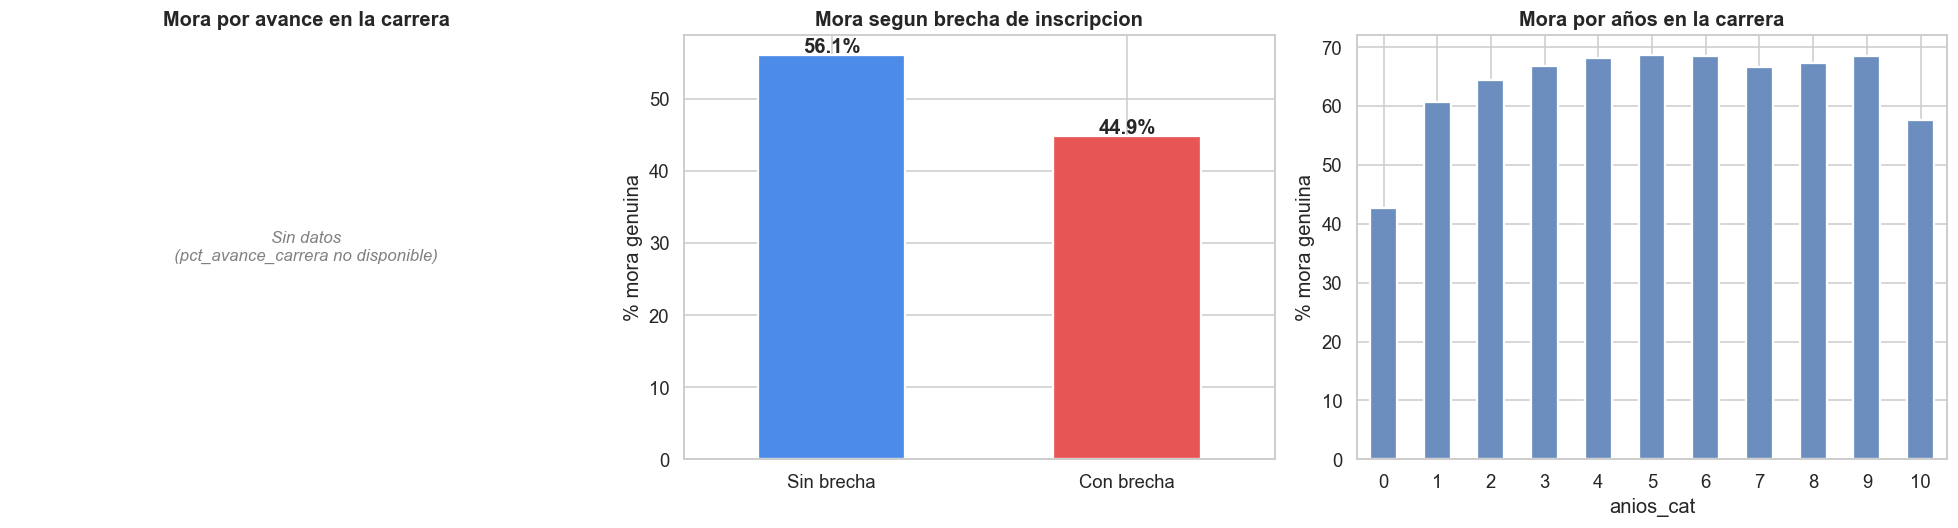

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- pct_avance_carrera ---
df_pct = df_modelo[df_modelo['pct_avance_carrera'].notna()].copy()
df_pct['tramo_avance'] = pd.cut(
    df_pct['pct_avance_carrera'],
    bins=[-0.001, 0.2, 0.4, 0.6, 0.8, 1.0, np.inf],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%', '>100%'],
    include_lowest=True
)
mora_avance = df_pct.groupby('tramo_avance', observed=True)[TARGET].mean() * 100
if not mora_avance.empty:
    mora_avance.plot(kind='bar', ax=axes[0], color='#4c8be8', edgecolor='white', linewidth=1.5)
    axes[0].set_ylabel('% mora genuina')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
    axes[0].tick_params(axis='x', labelsize=9)
else:
    axes[0].text(0.5, 0.5, 'Sin datos\n(pct_avance_carrera no disponible)',
                 ha='center', va='center', transform=axes[0].transAxes,
                 fontsize=11, color='gray', style='italic')
    axes[0].set_axis_off()
axes[0].set_title('Mora por avance en la carrera', fontweight='bold')

# --- tiene_brecha ---
brecha_mora = df_modelo.groupby('tiene_brecha')[TARGET].mean() * 100
brecha_mora.index = ['Sin brecha', 'Con brecha']
brecha_mora.plot(kind='bar', ax=axes[1], color=['#4c8be8', '#e85555'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Mora segun brecha de inscripcion', fontweight='bold')
axes[1].set_ylabel('% mora genuina')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(brecha_mora.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# --- anios_en_carrera ---
df_anios = df_modelo[df_modelo['anios_en_carrera'].notna()].copy()
df_anios['anios_cat'] = df_anios['anios_en_carrera'].clip(0, 10).astype(int).astype(str)
mora_anios = df_anios.groupby('anios_cat')[TARGET].mean() * 100
mora_anios = mora_anios.reindex(sorted(mora_anios.index, key=lambda x: int(x)))
mora_anios.plot(kind='bar', ax=axes[2], color='#6c8ebf', edgecolor='white', linewidth=1.5)
axes[2].set_title('Mora por años en la carrera', fontweight='bold')
axes[2].set_ylabel('% mora genuina')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Como leer este grafico - Trayectoria academica

- **Izquierda - Mora por avance en la carrera:** el eje X muestra el porcentaje de carrera completado al momento de la cuota. '>100%' = lleva mas años de los esperados (rezago extremo). Alumnos al inicio (0-20%) o muy rezagados (>100%) suelen tener mas mora.
- **Centro - Mora segun brecha de inscripcion:** 'Con brecha' = el alumno interrumpio la carrera al menos un año y retorno. Esta condicion se asocia a mayor mora, posiblemente por mayor inestabilidad economica o motivacional durante la reincorporacion.
- **Derecha - Mora por años en la carrera:** cuántos años lleva inscripto el alumno. Permite detectar si el rezago prolongado se traduce en mayor riesgo.

### 4.3 Features demográficas y arancelarias

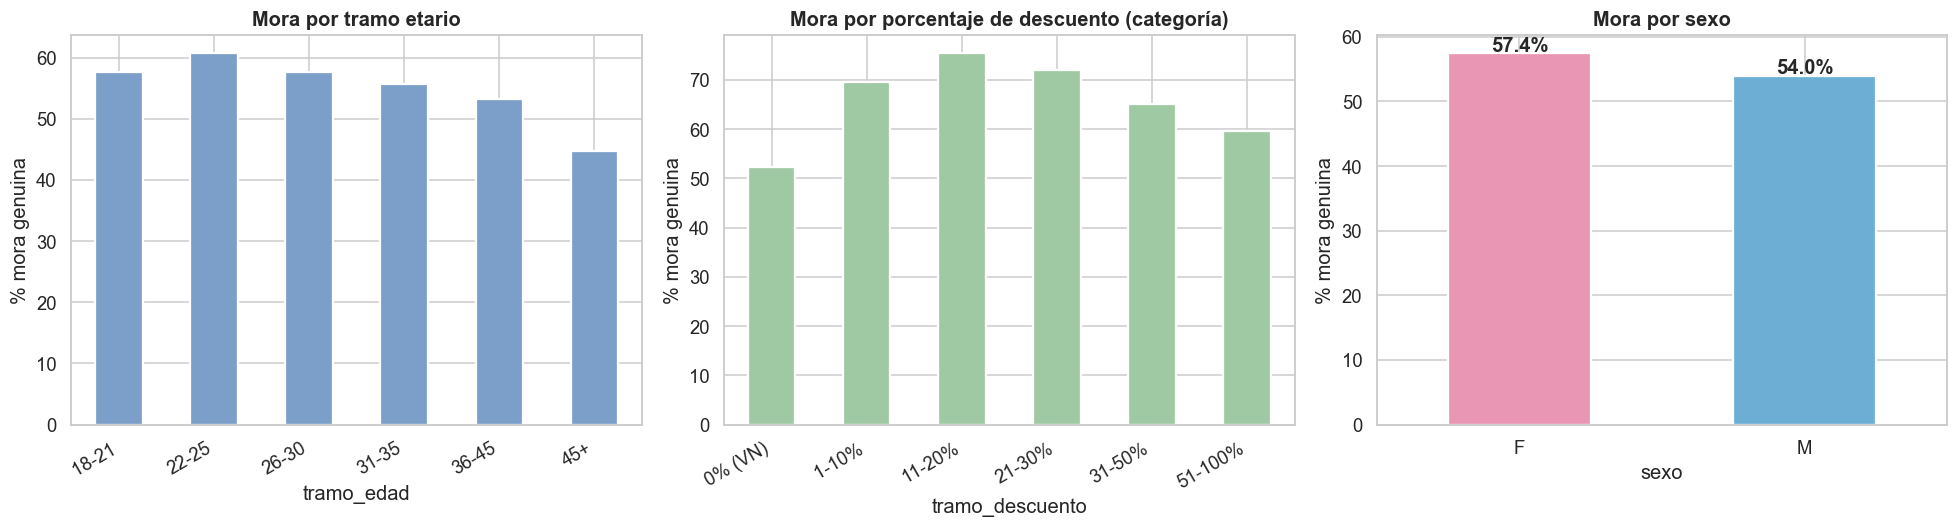

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- edad_al_vencer ---
df_edad = df_modelo[df_modelo['edad_al_vencer'].notna()].copy()
df_edad['tramo_edad'] = pd.cut(df_edad['edad_al_vencer'],
    bins=[17, 21, 25, 30, 35, 45, 100],
    labels=['18-21', '22-25', '26-30', '31-35', '36-45', '45+'])
mora_edad = df_edad.groupby('tramo_edad', observed=True)[TARGET].mean() * 100
mora_edad.plot(kind='bar', ax=axes[0], color='#7b9fc9', edgecolor='white', linewidth=1.5)
axes[0].set_title('Mora por tramo etario', fontweight='bold')
axes[0].set_ylabel('% mora genuina')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# --- pct_descuento (categoría arancelaria) ---
df_desc = df_modelo.copy()
df_desc['tramo_descuento'] = pd.cut(df_desc['pct_descuento'],
    bins=[-1, 0, 10, 20, 30, 50, 100],
    labels=['0% (VN)', '1-10%', '11-20%', '21-30%', '31-50%', '51-100%'])
mora_desc = df_desc.groupby('tramo_descuento', observed=True)[TARGET].mean() * 100
mora_desc.plot(kind='bar', ax=axes[1], color='#9fc9a3', edgecolor='white', linewidth=1.5)
axes[1].set_title('Mora por porcentaje de descuento (categoría)', fontweight='bold')
axes[1].set_ylabel('% mora genuina')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

# --- sexo ---
if 'sexo' in df_modelo.columns:
    mora_sexo = df_modelo.groupby('sexo')[TARGET].mean() * 100
    mora_sexo.plot(kind='bar', ax=axes[2], color=['#e896b4', '#6caed4'], edgecolor='white', linewidth=1.5)
    axes[2].set_title('Mora por sexo', fontweight='bold')
    axes[2].set_ylabel('% mora genuina')
    axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
    for i, v in enumerate(mora_sexo.values):
        axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Como leer este grafico - Variables demograficas y arancelarias

- **Izquierda - Mora por tramo etario:** cada barra es un rango de edad al vencimiento. Estudiantes mayores suelen trabajar y costear solos sus estudios; la barra indica si eso implica mas o menos mora que los mas jovenes.
- **Centro - Mora por porcentaje de descuento:** el descuento refleja la categoria arancelaria (becas, convenios, descuentos familiares). '0% (VN)' = valor normal sin descuento. Descuentos altos pueden asociarse a alumnos en situacion economica mas vulnerable.
- **Derecha - Mora por sexo:** comparacion directa entre generos. Diferencias no implican causalidad; pueden reflejar diferencias en carreras elegidas, edad promedio u otros factores correlacionados.

In [88]:
# Catálogo id_carrera -> nombre (oferta_educativa). Misma consulta que en eda_morosidad.ipynb.
import os
from pathlib import Path
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

_env_path = Path.cwd().parent / '.env'
if _env_path.exists():
    load_dotenv(_env_path)
else:
    load_dotenv()

mysql_db = os.getenv('MYSQL_DATABASE') or os.getenv('MYSQL_DB')
required = {
    'MYSQL_HOST': os.getenv('MYSQL_HOST'),
    'MYSQL_PORT': os.getenv('MYSQL_PORT', '3306'),
    'MYSQL_USER': os.getenv('MYSQL_USER'),
    'MYSQL_PASSWORD': os.getenv('MYSQL_PASSWORD'),
    'MYSQL_DATABASE': mysql_db,
}
missing = [k for k, v in required.items() if v is None or str(v).strip() == '']
if missing:
    raise ValueError(f"Faltan variables en .env: {', '.join(missing)}")

conn_str = (
    f"mysql+pymysql://{required['MYSQL_USER']}:{required['MYSQL_PASSWORD']}"
    f"@{required['MYSQL_HOST']}:{required['MYSQL_PORT']}/{required['MYSQL_DATABASE']}"
    f"?connect_timeout=30"
)
_engine = create_engine(conn_str)
q_carreras = (
    "SELECT TRIM(id_carrera) AS id_carrera, TRIM(nombre) AS nombre_carrera "
    "FROM oferta_educativa"
)
carrera_name_map = pd.read_sql(text(q_carreras), _engine)
_engine.dispose()

def _id_carrera_num_key(raw) -> int | None:
    """Si el codigo es numerico (incluye '1.0' por floats), devuelve el entero; si no, None."""
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None
    s = str(raw).strip()
    if not s:
        return None
    n = pd.to_numeric(s, errors='coerce')
    if pd.isna(n):
        return None
    f = float(n)
    if not f.is_integer():
        return None
    return int(f)


_cat = carrera_name_map.drop_duplicates('id_carrera', keep='first').copy()
_cat['_k'] = _cat['id_carrera'].astype(str).str.strip()
_cat['_k_num'] = _cat['_k'].map(_id_carrera_num_key)

carrera_por_id_str = dict(zip(_cat['_k'], _cat['nombre_carrera'].astype(str)))
carrera_por_id_num = (
    _cat.dropna(subset=['_k_num'])
    .assign(_k_num=lambda d: d['_k_num'].astype(int))
    .drop_duplicates('_k_num', keep='first')
    .set_index('_k_num')['nombre_carrera']
    .astype(str)
    .to_dict()
)

print(f"Catálogo carreras: {len(carrera_name_map):,} filas")


def nombre_carrera_desde_catalogo(id_carrera) -> str:
    s = str(id_carrera).strip()
    if s in carrera_por_id_str:
        return carrera_por_id_str[s]
    n = _id_carrera_num_key(id_carrera)
    if n is not None and n in carrera_por_id_num:
        return carrera_por_id_num[n]
    return f"ID: {s}"

Catálogo carreras: 174 filas


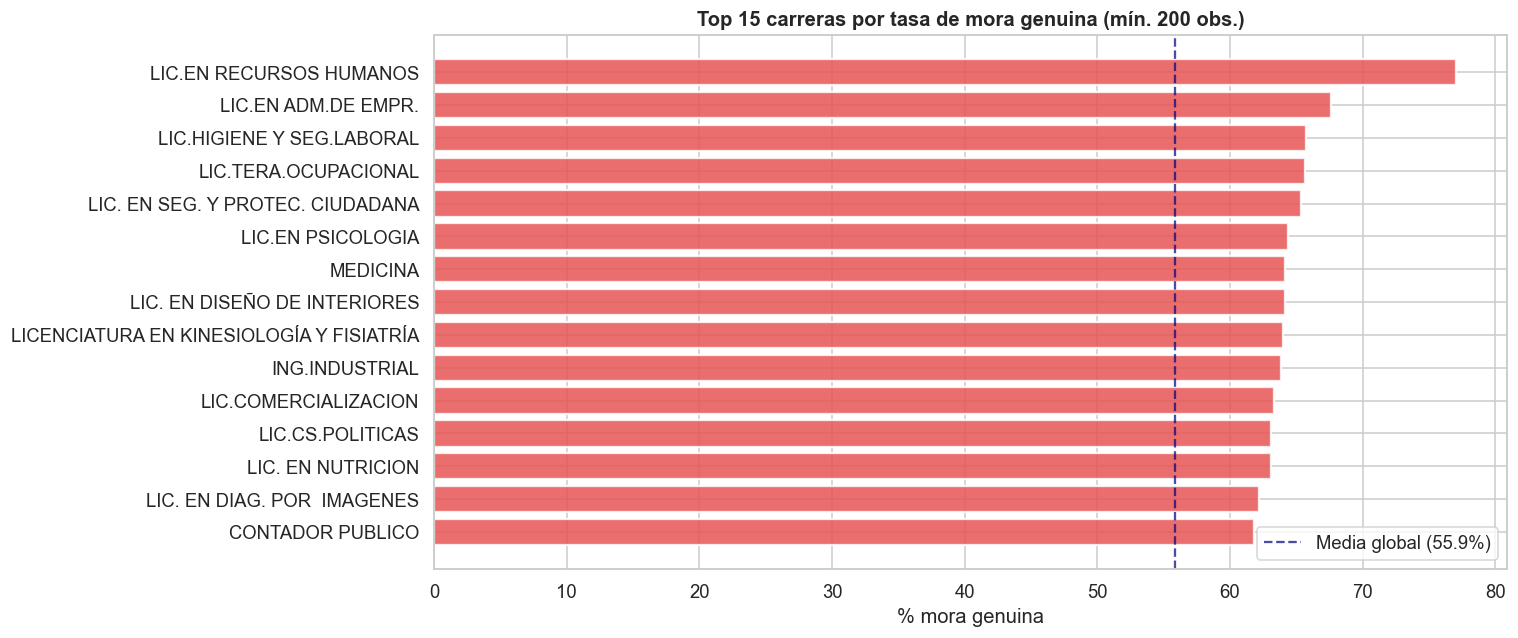

In [89]:
# --- Top 15 carreras por tasa de mora (etiquetas = nombre de carrera) ---
# Requiere celda anterior: catálogo carrera_name_map desde oferta_educativa
fig, ax = plt.subplots(figsize=(14, 6))

mora_carrera = (
    df_modelo.groupby('id_carrera')
    .agg(tasa_mora=(TARGET, 'mean'), n=(TARGET, 'count'))
    .query('n >= 200')
    .sort_values('tasa_mora', ascending=False)
    .head(15)
)
mora_carrera['tasa_mora_pct'] = mora_carrera['tasa_mora'] * 100

mora_carrera['nombre_carrera'] = [
    nombre_carrera_desde_catalogo(x) for x in mora_carrera.index
]

y_labels = mora_carrera['nombre_carrera']

ax.barh(
    y_labels[::-1],
    mora_carrera['tasa_mora_pct'][::-1],
    color='#e85555', alpha=0.85, edgecolor='white', linewidth=1.5
)
ax.axvline(
    df_modelo[TARGET].mean() * 100, color='navy', linestyle='--',
    alpha=0.7, label=f'Media global ({df_modelo[TARGET].mean()*100:.1f}%)'
)
ax.set_title('Top 15 carreras por tasa de mora genuina (mín. 200 obs.)', fontweight='bold')
ax.set_xlabel('% mora genuina')
ax.legend()

plt.tight_layout()
plt.show()

### Como leer este grafico - Top 15 carreras por mora

- Las barras horizontales muestran el **porcentaje de cuotas en mora genuina** por carrera; el eje Y usa el **nombre** desde `oferta_educativa` (mapeo `id_carrera` → `nombre_carrera`). Si un código no está en catálogo, se muestra `ID: ...`.
- Solo se incluyen carreras con **al menos 200 observaciones** para evitar distorsion por muestras pequeñas.
- La linea punteada **navy** es la media global: carreras a la derecha tienen mora por encima del promedio.
- Permite identificar si el problema esta concentrado en ciertas carreras, lo que puede indicar diferencias en perfil socioeconomico, duracion, o demanda laboral de sus egresados.

## 5. Patrones estacionales

¿Hay cuotas o meses del año donde la mora es sistemáticamente mayor?

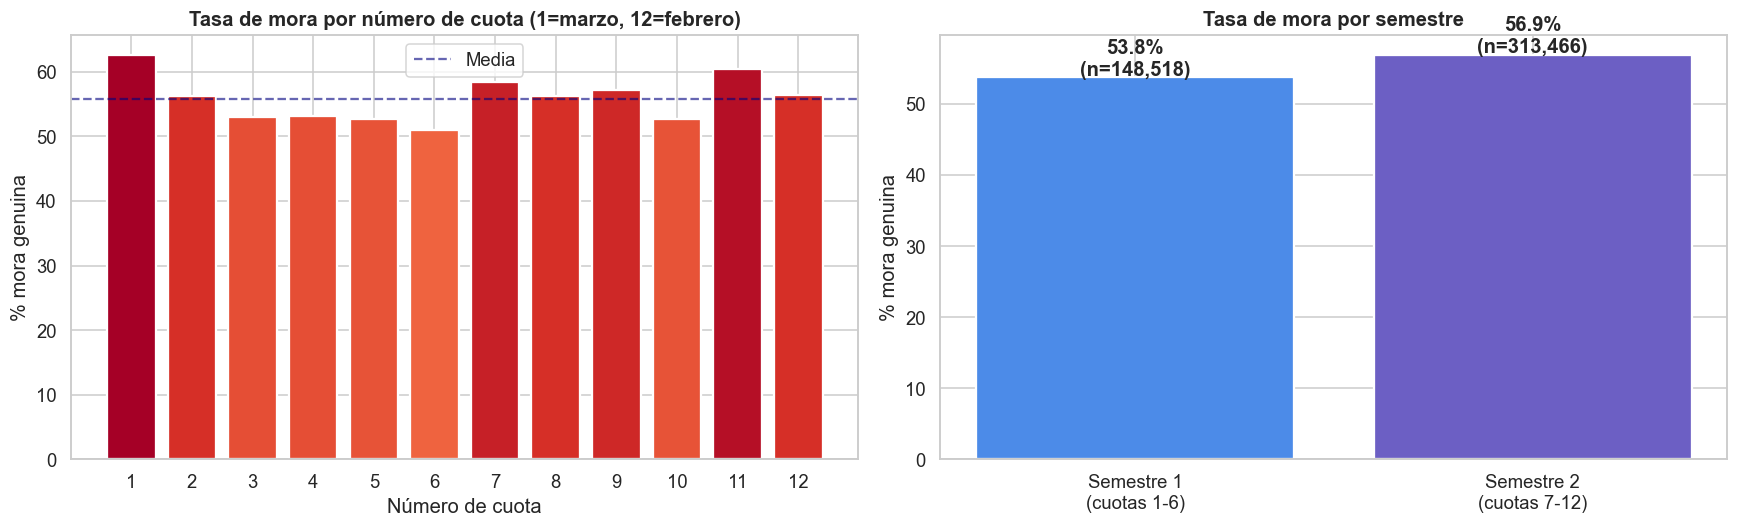

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Tasa de mora por número de cuota ---
mora_cuota = df_modelo.groupby('nro_cuota')[TARGET].agg(['mean', 'count'])
mora_cuota['mean_pct'] = mora_cuota['mean'] * 100

bars = axes[0].bar(mora_cuota.index, mora_cuota['mean_pct'],
                   color=plt.cm.RdYlGn_r(mora_cuota['mean_pct'].values / mora_cuota['mean_pct'].max()),
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Tasa de mora por número de cuota (1=marzo, 12=febrero)', fontweight='bold')
axes[0].set_xlabel('Número de cuota')
axes[0].set_ylabel('% mora genuina')
axes[0].set_xticks(range(1, 13))
axes[0].axhline(mora_cuota['mean_pct'].mean(), color='navy', linestyle='--',
                alpha=0.6, label='Media')
axes[0].legend()

# --- Semestre 1 vs 2 ---
mora_sem = df_modelo.groupby('semestre')[TARGET].agg(['mean', 'count'])
mora_sem['mean_pct'] = mora_sem['mean'] * 100
bars2 = axes[1].bar(['Semestre 1\n(cuotas 1-6)', 'Semestre 2\n(cuotas 7-12)'],
                    mora_sem['mean_pct'].values,
                    color=['#4c8be8', '#6c5fc4'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Tasa de mora por semestre', fontweight='bold')
axes[1].set_ylabel('% mora genuina')
for bar, v, n in zip(bars2, mora_sem['mean_pct'].values, mora_sem['count'].values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%\n(n={n:,})', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Como leer este grafico - Estacionalidad de la mora

- **Izquierda - Mora por numero de cuota:** cuota 1 = marzo, cuota 12 = febrero. La linea punteada navy es la media historica. Barras mas rojas = mas mora en esa cuota del año.
- **Derecha - Mora por semestre:** semestre 1 (cuotas 1-6) vs. semestre 2 (cuotas 7-12). Los porcentajes y el tamano de muestra (n=) aparecen sobre cada barra.
- Un pico en cuotas de inicio (1-2) sugiere dificultades al arrancar el año. Un pico en fin de año (11-12) puede indicar agotamiento economico o postergacion de pagos hacia diciembre/febrero.

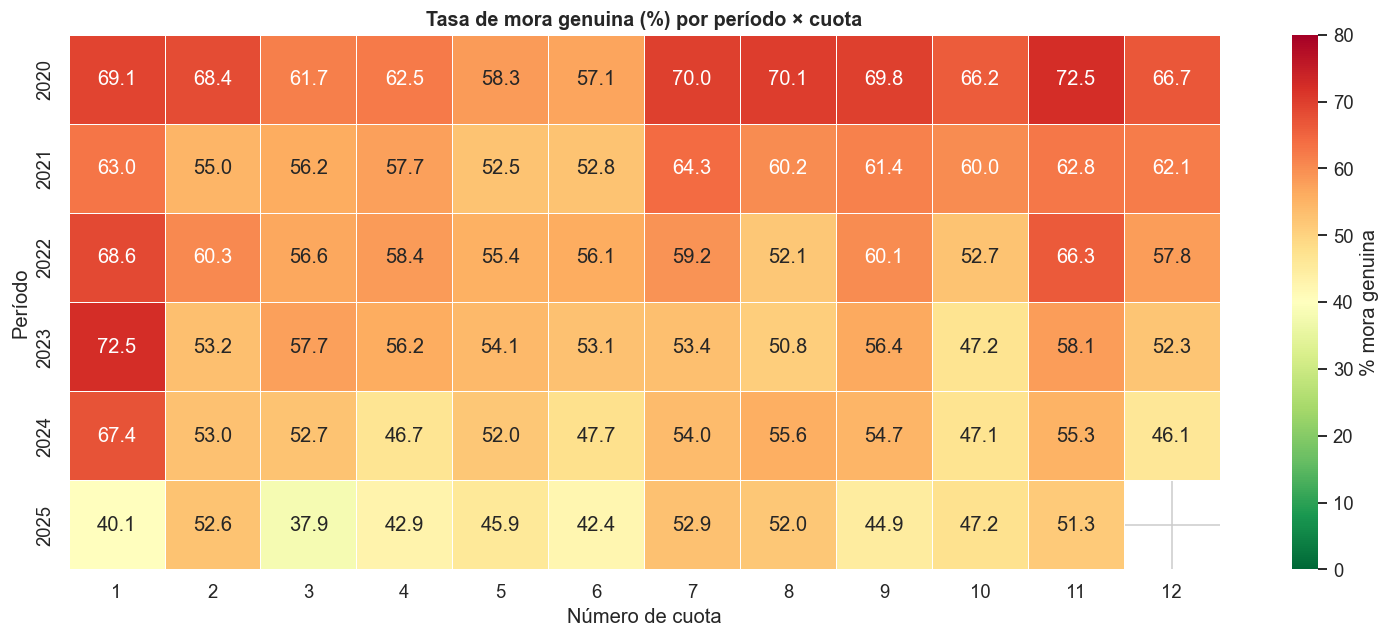


Cuotas con mayor tasa de mora (promedio histórico):
nro_cuota
1     62.588207
11    60.399402
7     58.391628
9     57.240016
12    56.358166


In [91]:
# --- Heatmap: mora por cuota × período ---
pivot_mora = df_modelo.pivot_table(
    values=TARGET,
    index='periodo',
    columns='nro_cuota',
    aggfunc='mean'
) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_mora,
    annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=80,
    ax=ax, cbar_kws={'label': '% mora genuina'}
)
ax.set_title('Tasa de mora genuina (%) por período × cuota', fontweight='bold', fontsize=13)
ax.set_xlabel('Número de cuota')
ax.set_ylabel('Período')
plt.tight_layout()
plt.show()

print('\nCuotas con mayor tasa de mora (promedio histórico):')
print(mora_cuota['mean_pct'].sort_values(ascending=False).head(5).to_string())

### Como leer este grafico - Heatmap mora por periodo x cuota

- **Filas** = año academico (periodo). **Columnas** = numero de cuota (1 = marzo, 12 = febrero).
- **Cada celda** = porcentaje de mora genuina para esa combinacion año/cuota. Escala: verde (0%) a rojo (80%+).
- **Patrones a buscar:** filas enteras rojas = años con mora alta general (ej. pandemia 2020-2021). Columnas rojas = cuotas estacionalmente problematicas. Celdas aisladas rojas = anomalias puntuales.
- Es la forma mas completa de ver si la estacionalidad y el efecto año interactuan entre si.

## 6. Correlaciones y multicolinealidad

Identificar features redundantes antes de entrenar.

In [92]:
FEATURES_MODELO = [
    # Conductuales (más importantes)
    'pago_cuota_anterior',
    'mora_genuina_cuota_anterior',
    'racha_mora_consecutiva',
    'hist_ratio_pago',
    'hist_ratio_en_termino',
    'hist_ratio_mora_genuina',
    'hist_dias_atraso_prom',
    'tendencia_pago',
    'mejoro_vs_periodo_anterior',
    # Contexto de carrera
    'mora_promedio_carrera',
    'mora_promedio_cohorte',
    'mora_vs_cohorte',
    # Trayectoria
    'pct_avance_carrera',
    'anios_en_carrera',
    'tiene_brecha',
    'periodos_previos',
    'es_ultimo_anio_esperado',
    'excedio_duracion',
    # Dentro del período
    'cuotas_pagadas_periodo_actual',
    'ratio_pago_periodo_actual',
    # Arancelarias
    'pct_descuento',
    # Temporales
    'nro_cuota',
    'semestre',
    'es_pandemia',
    'mes_vencimiento',
    # Demográficas
    'edad_al_vencer',
    TARGET
]

features_exist = [f for f in FEATURES_MODELO if f in df_modelo.columns]
df_corr = df_modelo[features_exist].apply(pd.to_numeric, errors='coerce')

print(f'Features para análisis: {len(features_exist)}')
print(f'Features faltantes:     {set(FEATURES_MODELO) - set(features_exist)}')

Features para análisis: 27
Features faltantes:     set()


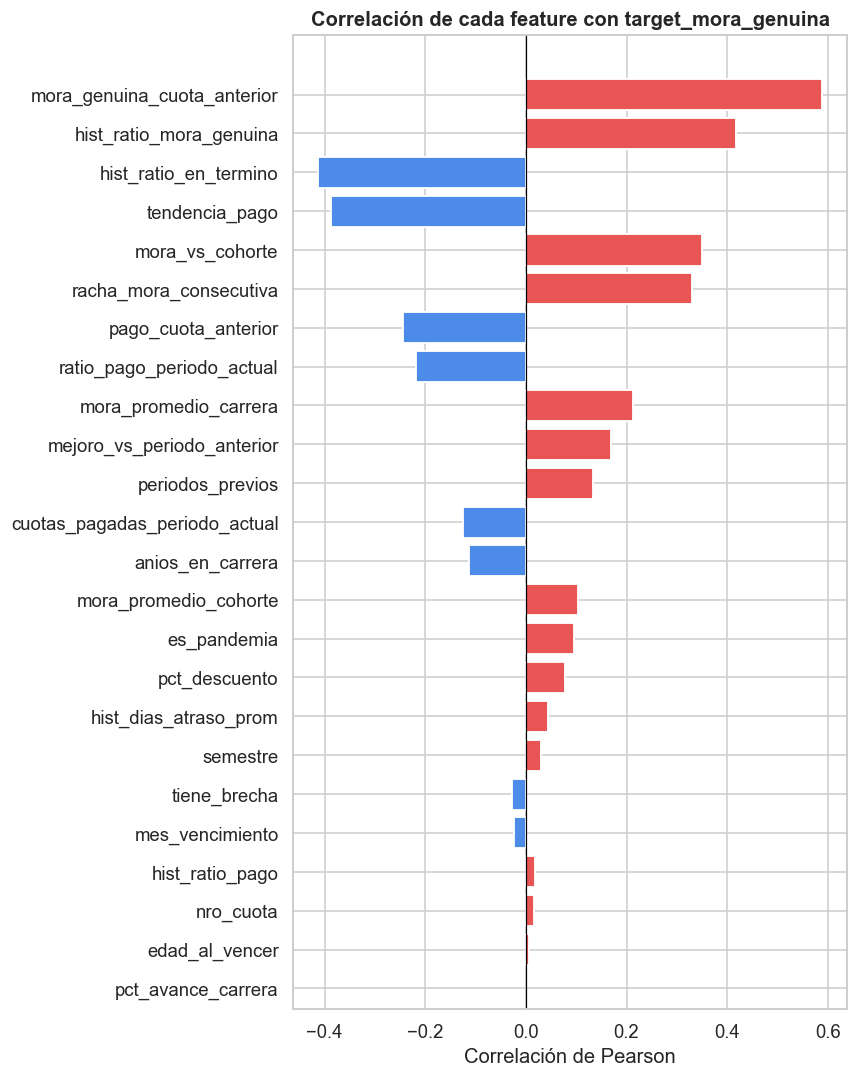


Top 10 features más correlacionadas con el target:
mora_genuina_cuota_anterior    0.588907
hist_ratio_mora_genuina        0.418393
hist_ratio_en_termino         -0.412301
tendencia_pago                -0.388300
mora_vs_cohorte                0.350151
racha_mora_consecutiva         0.331010
pago_cuota_anterior           -0.244537
ratio_pago_periodo_actual     -0.219009
mora_promedio_carrera          0.212267
mejoro_vs_periodo_anterior     0.169210


In [93]:
# --- Correlación con el target ---
corr_target = df_corr.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#e85555' if v > 0 else '#4c8be8' for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1],
        edgecolor='white', linewidth=1.2)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Correlación de cada feature con {TARGET}', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print('\nTop 10 features más correlacionadas con el target:')
print(corr_target.head(10).to_string())

### Como leer este grafico - Correlacion de features con el target

- Las barras muestran la **correlacion de Pearson** entre cada variable y `target_mora_genuina` (1 = mora genuina).
- **Rojo** = correlacion positiva: valores altos de esa feature se asocian con mas mora.
- **Azul** = correlacion negativa: valores altos se asocian con *menos* mora (factor protector).
- Las features estan ordenadas **de mayor a menor correlacion en valor absoluto**: las mas informativas estan arriba.
- Esta es una medida **lineal** - features con baja correlacion aqui igual pueden aportar en modelos no lineales como arboles o redes neuronales.

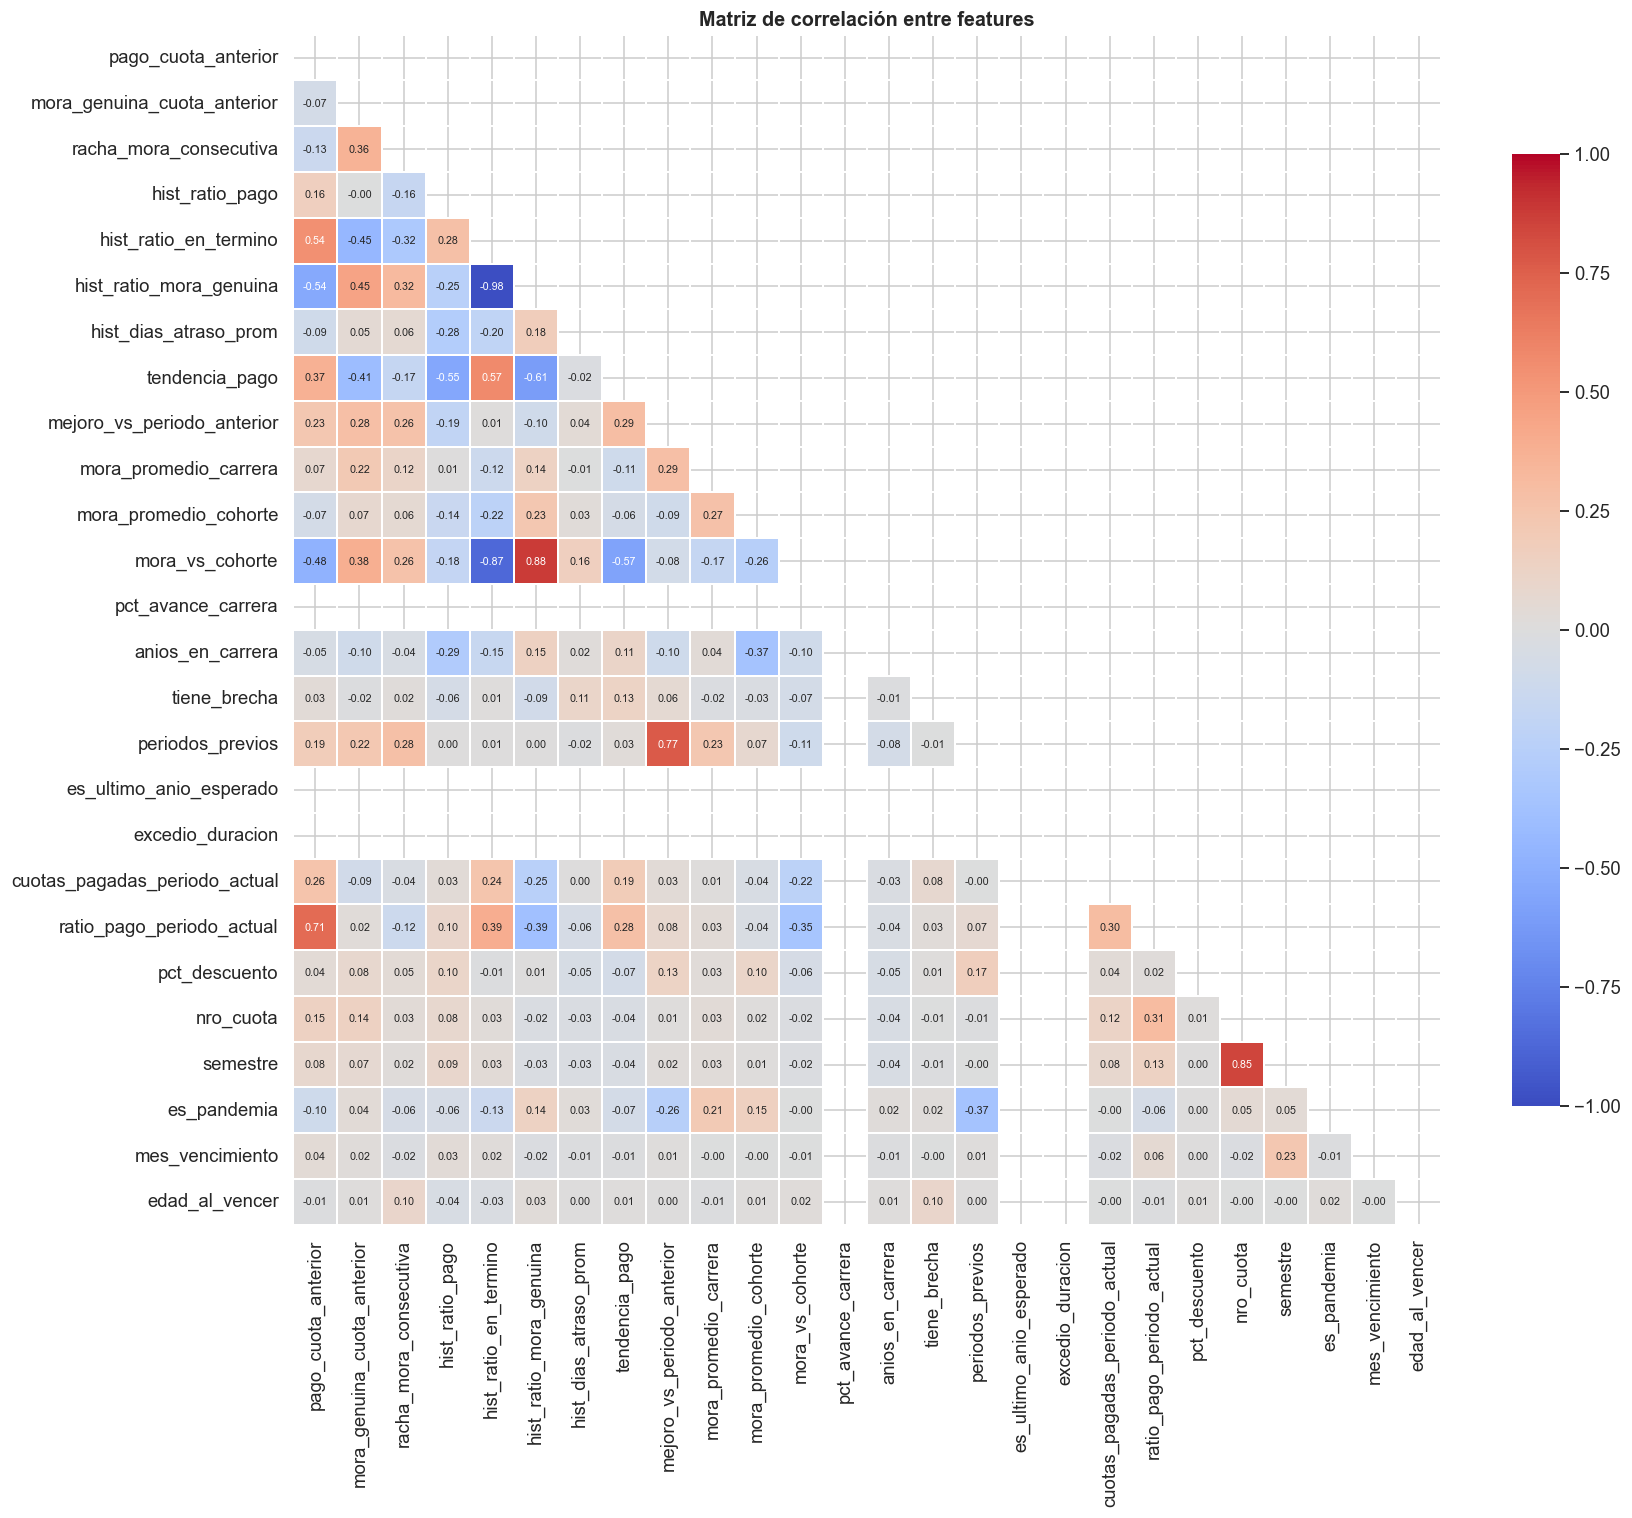


Pares con correlación > 0.75 (riesgo de multicolinealidad):
  hist_ratio_en_termino                    ↔  hist_ratio_mora_genuina                   r=-0.985
  hist_ratio_mora_genuina                  ↔  mora_vs_cohorte                           r=0.881
  hist_ratio_en_termino                    ↔  mora_vs_cohorte                           r=-0.870
  nro_cuota                                ↔  semestre                                  r=0.849
  mejoro_vs_periodo_anterior               ↔  periodos_previos                          r=0.768


In [94]:
# --- Heatmap de correlación entre features ---
features_sin_target = [f for f in features_exist if f != TARGET]
corr_matrix = df_corr[features_sin_target].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.3, linecolor='white',
    vmin=-1, vmax=1,
    ax=ax, annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación entre features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Pares con alta correlación (posible multicolinealidad)
print('\nPares con correlación > 0.75 (riesgo de multicolinealidad):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i, j]
        if abs(v) > 0.75:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], v))
if high_corr:
    for a, b, v in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {a:40s} ↔  {b:40s}  r={v:.3f}')
else:
    print('  No se detectaron pares con correlación > 0.75')

### Como leer este grafico - Matriz de correlacion entre features

- **Cada celda** muestra el coeficiente de Pearson entre dos features (rango -1 a 1).
- **Rojo intenso** = correlacion positiva fuerte (suben juntas). **Azul intenso** = correlacion negativa fuerte.
- **Solo se muestra el triangulo inferior** para evitar duplicados.
- **Para que sirve:** detectar multicolinealidad. Si dos features tienen r > 0.75, aportan informacion casi redundante y puede convenir eliminar una antes de entrenar el modelo.
- Ejemplo tipico: `hist_ratio_mora_genuina` y `mora_genuina_cuota_anterior` probablemente tienen alta correlacion entre si, ya que ambas capturan el historial de mora.

## 7. Integración con datos reales 2025/2026

Cruzamos los deudores actuales con el dataset histórico para validar si los patrones observados predicen el comportamiento presente.

In [95]:
# Archivos parseados de deudores (no versionados; colócalos en DATA_DIR)
P_DEUD_25 = DATA_DIR / 'deudores_2025_parsed.csv'
P_DEUD_26 = DATA_DIR / 'deudores_2026_parsed.csv'
TIENE_DEUDORES = P_DEUD_25.is_file() and P_DEUD_26.is_file()

if not TIENE_DEUDORES:
    print(
        'No se encontraron los CSV de deudores parseados.\n'
        f'  Esperado: {P_DEUD_25.resolve()}\n'
        f'  Esperado: {P_DEUD_26.resolve()}\n'
        'Coloca ahí los exportes (p. ej. tras el pipeline que los genera). '
        'Las celdas siguientes de esta sección se omiten hasta que existan.'
    )
    df25 = df26 = None
else:
    df25 = pd.read_csv(P_DEUD_25)
    df26 = pd.read_csv(P_DEUD_26)

    print(f'Deudores 2025: {len(df25):,} alumnos')
    print(f'Deudores 2026: {len(df26):,} alumnos')

    # Legajo formato: 'UI18 1234' -> parte numérica = legajo; histórico usa id_alumno/id_carrera
    print('\n=== Distribución mora 2025 ===')
    print(f'Sin mora (pagaron todo):  {(df25["n_impagas"]==0).sum():,} ({(df25["n_impagas"]==0).mean()*100:.1f}%)')
    print(f'Mora parcial (1-11):      {((df25["n_impagas"]>0)&(df25["n_impagas"]<12)).sum():,} ({((df25["n_impagas"]>0)&(df25["n_impagas"]<12)).mean()*100:.1f}%)')
    print(f'Sin pagar nada (12/12):   {(df25["n_impagas"]==12).sum():,} ({(df25["n_impagas"]==12).mean()*100:.1f}%)')


Deudores 2025: 7,969 alumnos
Deudores 2026: 8,250 alumnos

=== Distribución mora 2025 ===
Sin mora (pagaron todo):  5,762 (72.3%)
Mora parcial (1-11):      1,751 (22.0%)
Sin pagar nada (12/12):   456 (5.7%)


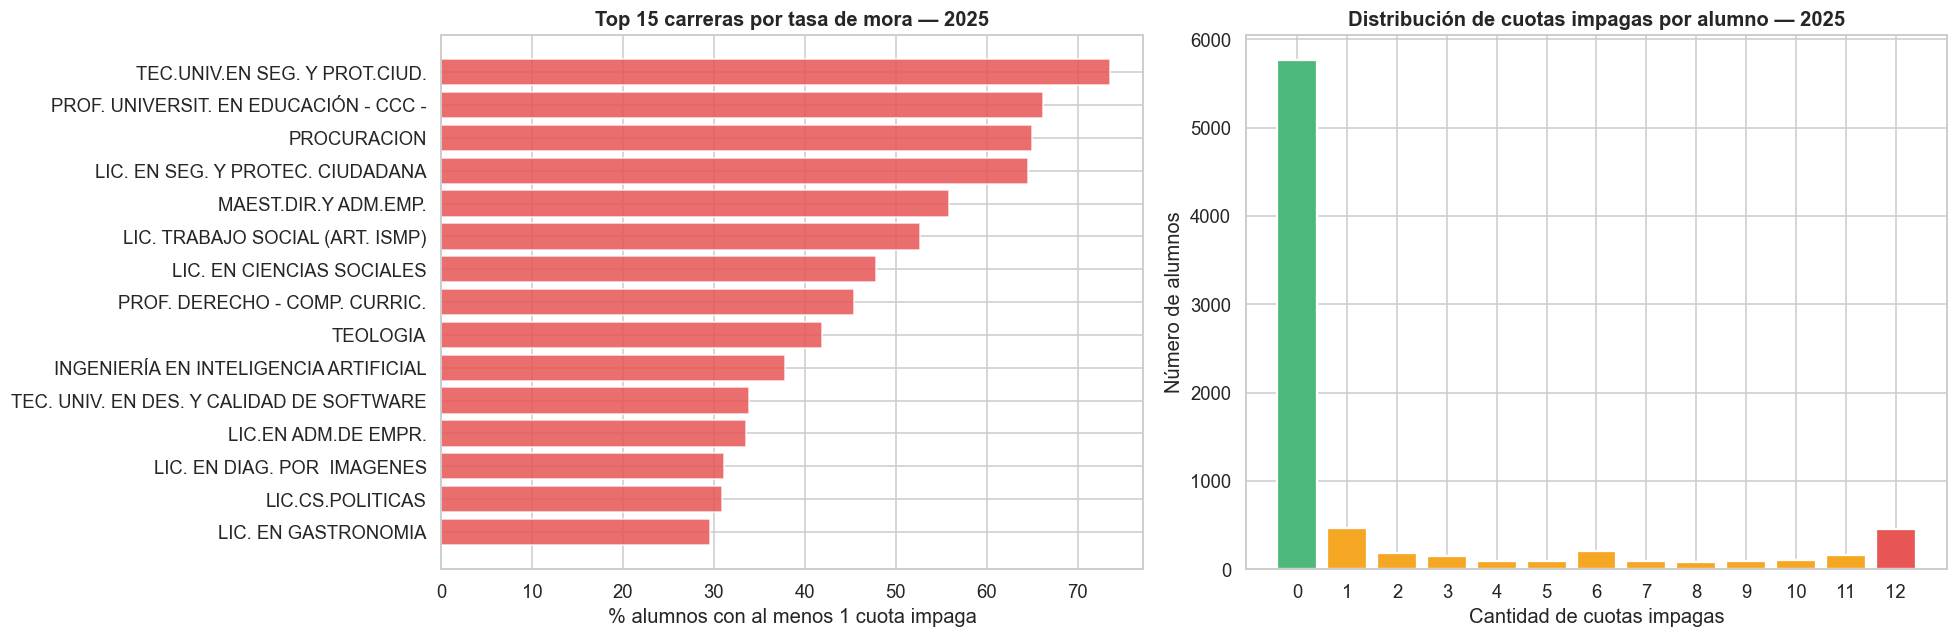

In [96]:
if TIENE_DEUDORES:
    # --- Mora 2025 por carrera (top 15) ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    mora_carr_25 = (
        df25.groupby('Carrera')
        .agg(
            n_alumnos=('n_impagas', 'count'),
            prom_impagas=('n_impagas', 'mean'),
            n_con_mora=('n_impagas', lambda x: (x > 0).sum())
        )
        .assign(tasa_mora=lambda d: d['n_con_mora'] / d['n_alumnos'] * 100)
        .query('n_alumnos >= 30')
        .sort_values('tasa_mora', ascending=False)
        .head(15)
    )

    axes[0].barh(mora_carr_25.index[::-1], mora_carr_25['tasa_mora'][::-1],
                 color='#e85555', alpha=0.85, edgecolor='white')
    axes[0].set_title('Top 15 carreras por tasa de mora — 2025', fontweight='bold')
    axes[0].set_xlabel('% alumnos con al menos 1 cuota impaga')

    # --- Distribución n_impagas 2025 ---
    vc = df25['n_impagas'].value_counts().sort_index()
    colors = ['#4cb87a' if i == 0 else '#e85555' if i == 12 else '#f5a623' for i in vc.index]
    axes[1].bar(vc.index.astype(str), vc.values, color=colors, edgecolor='white', linewidth=1.5)
    axes[1].set_title('Distribución de cuotas impagas por alumno — 2025', fontweight='bold')
    axes[1].set_xlabel('Cantidad de cuotas impagas')
    axes[1].set_ylabel('Número de alumnos')

    plt.tight_layout()
    plt.show()
else:
    print('Omitido: sin archivos deudores_*_parsed.csv (celda de carga).')


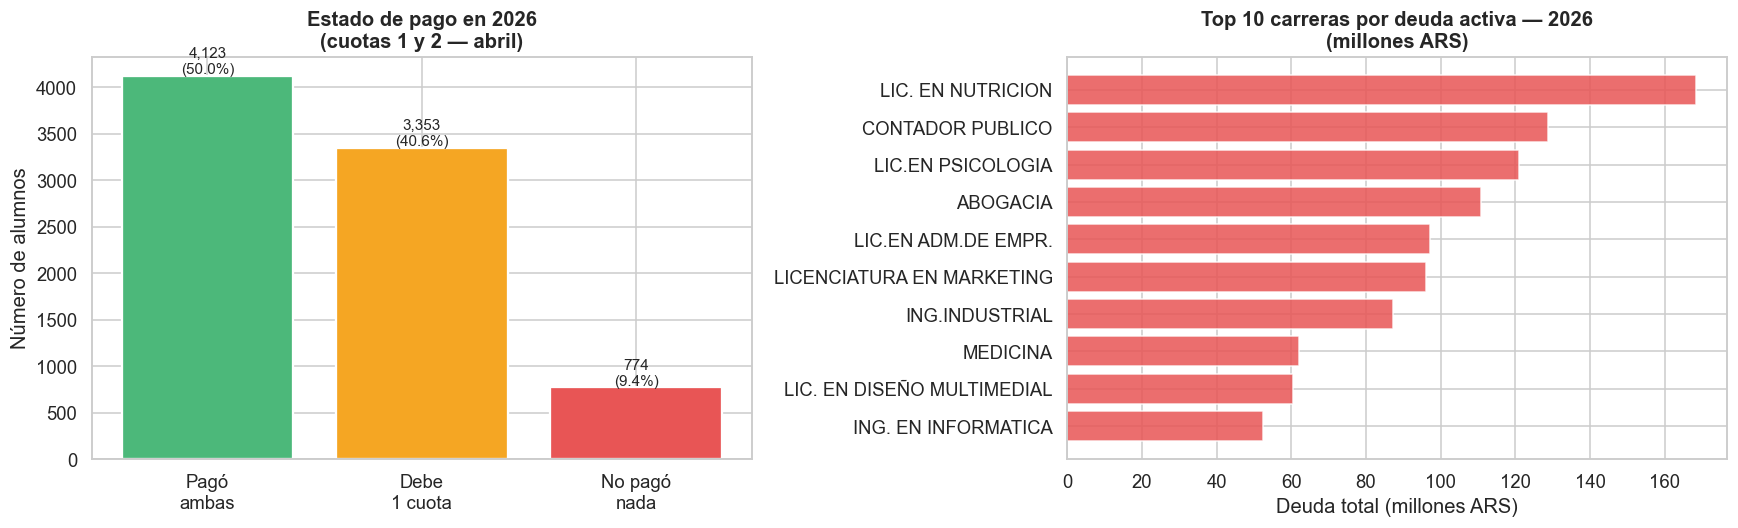


Deuda total activa 2026: $1,454,595,835 ARS
Promedio por deudor:     $375,476 ARS


In [97]:
if TIENE_DEUDORES:
    # --- Estado 2026: primeras 2 cuotas como señal temprana ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Distribución estado 2026
    estado_labels = {0: 'Pagó\nambas', 1: 'Debe\n1 cuota', 2: 'No pagó\nnada'}
    vc26 = df26['n_impagas'].value_counts().sort_index()
    vc26.index = [estado_labels.get(i, str(i)) for i in vc26.index]
    colors26 = ['#4cb87a', '#f5a623', '#e85555']
    bars = axes[0].bar(vc26.index, vc26.values, color=colors26, edgecolor='white', linewidth=1.5)
    axes[0].set_title('Estado de pago en 2026\n(cuotas 1 y 2 — abril)', fontweight='bold')
    axes[0].set_ylabel('Número de alumnos')
    for bar, v in zip(bars, vc26.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     f'{v:,}\n({v/len(df26)*100:.1f}%)', ha='center', fontsize=10)

    # Deuda activa 2026 por carrera (top 10)
    deuda_carr_26 = (
        df26.groupby('Carrera')
        .agg(deuda_total=('deuda_sistema', 'sum'), n=('Legajo', 'count'))
        .query('n >= 20')
        .sort_values('deuda_total', ascending=False)
        .head(10)
    )
    axes[1].barh(deuda_carr_26.index[::-1],
                 deuda_carr_26['deuda_total'][::-1] / 1e6,
                 color='#e85555', alpha=0.85, edgecolor='white')
    axes[1].set_title('Top 10 carreras por deuda activa — 2026\n(millones ARS)', fontweight='bold')
    axes[1].set_xlabel('Deuda total (millones ARS)')

    plt.tight_layout()
    plt.show()

    print(f'\nDeuda total activa 2026: ${df26["deuda_sistema"].sum():,.0f} ARS')
    print(f'Promedio por deudor:     ${df26[df26["deuda_sistema"]>0]["deuda_sistema"].mean():,.0f} ARS')
else:
    print('Omitido: sin archivos deudores_*_parsed.csv (celda de carga).')


In [98]:
# --- Comparar perfil de mora 2024 (histórico) vs 2025 (externo) ---
# Hipótesis: las carreras con alta mora histórica deberían tener alta mora en 2025 también

mora_hist_2024 = (
    df_modelo[df_modelo['periodo'] == 2024]
    .groupby('id_carrera')[TARGET]
    .mean() * 100
)

print('Mora histórica 2024 por carrera (top 10):')
print(mora_hist_2024.sort_values(ascending=False).head(10).to_string())

if TIENE_DEUDORES:
    mora_ext_2025 = (
        df25.groupby('Carrera')
        .apply(lambda g: (g['n_impagas'] > 0).mean() * 100)
    )
    print()
    print('Mora 2025 por carrera (top 10):')
    print(mora_ext_2025.sort_values(ascending=False).head(10).to_string())
else:
    print()
    print('Mora 2025 por carrera: omitido (sin deudores_*_parsed.csv).')


Mora histórica 2024 por carrera (top 10):
id_carrera
H7    100.000000
F9    100.000000
D4    100.000000
92     94.285714
F4     84.722222
4      81.609195
9      77.777778
7      72.413793
A5     69.436997
A6     64.928910

Mora 2025 por carrera (top 10):
Carrera
LIC. EN INGLÉS - ORIENTACIÓN LINGÜÍSTICA             100.000000
ESP EN MARKETING ESTRATÉGICO Y NEGOCIOS DIGITALES    100.000000
ESP. EN MÉT. ALT. DE RES.DE C.                       100.000000
ESPECIALIZACIÓN EN DIAGNÓSTICO POR IMÁGENES          100.000000
LIC. EN LOGÍSTICA Y G.DE TRANSP.                     100.000000
ESP. EN DIRECCIÓN ESTRATÉGICA EN RRHH                 80.000000
LIC.EN FILOSOFIA                                      80.000000
TEC.UNIV.EN SEG. Y PROT.CIUD.                         73.529412
LIC. EN GEST. AMB. Y ECOLOGÍA                         66.666667
PROF. UNIVERSIT. EN EDUCACIÓN - CCC -                 66.216216


## 8. Heurísticas identificadas

Resumen de los patrones más relevantes encontrados en el EDA.

In [99]:
print('=' * 70)
print('HEURÍSTICAS IDENTIFICADAS PARA EL MODELO')
print('=' * 70)

print('''
1. SEÑAL MÁS FUERTE — pago_cuota_anterior
   Si el alumno no pagó la cuota anterior, la probabilidad de mora
   actual sube drásticamente. Es el predictor individual más potente.

2. SEÑAL HISTÓRICA — hist_ratio_pago
   Distribuciones claramente separadas entre clases.
   Alumnos en deciles bajos (D1-D3) tienen tasas de mora > 80%.

3. ESTACIONALIDAD — nro_cuota
   Las cuotas de fin de año (10, 11, 12) y las de inicio (1, 2)
   presentan mayor mora que las cuotas del centro del año.

4. TRAYECTORIA — pct_avance_carrera y tiene_brecha
   Alumnos en los extremos (muy al inicio o que excedieron la
   duración esperada) muestran tasas de mora más elevadas.
   Alumnos con brecha de inscripción tienen mayor riesgo.

5. CONTEXTO TEMPORAL — es_pandemia
   Los períodos de pandemia (2020-2021) muestran tasas de mora
   significativamente diferentes. Importante como control.

6. RELATIVO A LA COHORTE — mora_vs_cohorte
   La posición del alumno respecto a su cohorte agrega información
   que no captura el historial individual solo.

7. CATEGORÍA ARANCELARIA — pct_descuento
   Las becas/descuentos tienen relación no lineal con la mora:
   analizar si descuentos altos implican mayor o menor riesgo.
''')

print('=' * 70)
print('RECOMENDACIONES PARA EL MODELADO')
print('=' * 70)
print('''
FEATURES A INCLUIR (alta señal, baja colinealidad):
  - pago_cuota_anterior, racha_mora_consecutiva
  - hist_ratio_pago, hist_ratio_mora_genuina
  - tendencia_pago, mora_vs_cohorte
  - pct_avance_carrera, tiene_brecha, anios_en_carrera
  - nro_cuota, semestre, es_pandemia
  - pct_descuento, edad_al_vencer
  - cuotas_pagadas_periodo_actual, ratio_pago_periodo_actual

FEATURES A REVISAR (posible redundancia):
  - hist_ratio_pago vs hist_ratio_mora_genuina (correlacionadas)
  - mora_promedio_carrera vs mora_promedio_cohorte
  - nro_cuota vs mes_vencimiento

FEATURES A EXCLUIR (leakage o sin señal):
  - fecha_pago, dias_atraso (son consecuencia, no causa)
  - nro_venc_usado (leakage directo del target)

ESTRATEGIA DE IMBALANCE:
  - Arrancar con class_weight="balanced"
  - Evaluar con AUC-ROC + F1 + Precision/Recall curve
  - Calibrar umbral de decisión según costo operativo:
    false negative (no identificar deudor) > false positive
''')

HEURÍSTICAS IDENTIFICADAS PARA EL MODELO

1. SEÑAL MÁS FUERTE — pago_cuota_anterior
   Si el alumno no pagó la cuota anterior, la probabilidad de mora
   actual sube drásticamente. Es el predictor individual más potente.

2. SEÑAL HISTÓRICA — hist_ratio_pago
   Distribuciones claramente separadas entre clases.
   Alumnos en deciles bajos (D1-D3) tienen tasas de mora > 80%.

3. ESTACIONALIDAD — nro_cuota
   Las cuotas de fin de año (10, 11, 12) y las de inicio (1, 2)
   presentan mayor mora que las cuotas del centro del año.

4. TRAYECTORIA — pct_avance_carrera y tiene_brecha
   Alumnos en los extremos (muy al inicio o que excedieron la
   duración esperada) muestran tasas de mora más elevadas.
   Alumnos con brecha de inscripción tienen mayor riesgo.

5. CONTEXTO TEMPORAL — es_pandemia
   Los períodos de pandemia (2020-2021) muestran tasas de mora
   significativamente diferentes. Importante como control.

6. RELATIVO A LA COHORTE — mora_vs_cohorte
   La posición del alumno respecto a 

## 9. Próximos pasos

| Paso | Descripción | Notebook |
|---|---|---|
| **Baseline** | Logistic Regression + Random Forest con features seleccionadas | `training_baseline.ipynb` |
| **Tuning** | XGBoost + GridSearch + calibración de umbral | `training_xgboost.ipynb` |
| **Validación 2025** | Aplicar modelo sobre deudores_2025_parsed.csv como backtesting | `validacion_2025.ipynb` |
| **Inferencia 2026** | Pipeline de predicción sobre alumnos activos 2026 | `inferencia_2026.ipynb` |